# Análisis de perfil y desempeño 08/06/2026

Influeixen l’antiguitat, la càrrega laboral diària o la distància fins al lloc de treball en el rendiment dels nostres col·laboradors?
Podem identificar perfils amb major risc de baix rendiment i fer ajustaments en l’organització per potenciar els resultats?

Mensaje de Verónica:  
En vuestro caso hay que dosificar más el esfuerzo y la complejidad. He contado 6 técnicas creo para una pregunta que a nivel general es sencilla.  

Recomiendo ir por descriptivo + una técnica más (o bien RLM si el score lo trabajan como variable continua o regresión logística multinomial si la trabajan como categórica). En vuestro caso, diría que el "error" está en intentar deducir de cada parte de la pregunta una técnica de análisis. 

Queda por hacer:
- Gráficos "bonitos" distribución Score rendimiento (agrupado por ID)
- Influencia (Noelia)
    - Spearman
    - RLM
- Perfiles (Sabina)
    - Definir los perfiles
    - Descriptivos generales y de los perfiles
    - Multinomial

# Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np
import plotly.graph_objs as go
import seaborn as sns
from scipy.stats import spearmanr 
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler


# Funciones

In [2]:
def distr_hist(df: pd.DataFrame, column: str, bars: int) -> None:
    """
    Muestra un histograma para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    bars : int
        Número de barras del histograma.
    """
    plt.hist(df[column], bins=bars)
    plt.title(f'Distribución de la variable {column}')
    plt.show()

In [3]:
def distr_value(df: pd.DataFrame, column: str) -> None:
    """
    Muestra la distribución porcentual y los valores únicos de una columna.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a analizar.
    """
    value_count = df[column].value_counts(normalize=True)*100
    print(f'Value counts: {value_count}')
    val_unique = df[column].unique()
    print(f'----\nValores únicos:{val_unique}')
    
    print('----\nGráfico distribución valores únicos:')
    (df[column]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind='bar'))

    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Hit_target')
    plt.title('Distribución de Hit_target')
    plt.show()                  

In [4]:
def distr_boxplot(df: pd.DataFrame, column: str) -> None:
    """
    Muestra un boxplot para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    """
    plt.boxplot(df[column])
    plt.title(f'Boxplot de la variable {column}')
    plt.show()

In [5]:
def outliers_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Devuelve las filas con valores atípicos en una columna usando el método IQR.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna numérica a analizar.
    """
    col = df[column]

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    limit_inferior = Q1 - 1.5 * IQR
    limit_superior = Q3 + 1.5 * IQR

    outliers = df[(col < limit_inferior) | (col > limit_superior)]
    
    return outliers

# Documento

In [6]:
df_RRHH = pd.read_csv('../../Data/clean/clean_data_08062026.csv')
df_RRHH

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,...,2,0,0,1,65,172,22,22.0,112,2026-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1104,22,1.0,Enfermedades infecciosas y parasitarias,4.0,Abril,4,Miércoles,2,Primavera,179,...,0,0,0,0,56,171,19,19.2,64,2026-06-08
1105,26,19.0,"Lesiones, intoxicaciones y consecuencias externas",11.0,Noviembre,6,Viernes,4,Otoño,300,...,2,1,1,1,77,175,25,25.1,64,2026-06-08
1106,34,19.0,"Lesiones, intoxicaciones y consecuencias externas",6.0,Junio,3,Martes,2,Primavera,118,...,0,0,0,0,83,172,28,28.1,56,2026-06-08
1107,20,19.0,"Lesiones, intoxicaciones y consecuencias externas",10.0,Octubre,6,Viernes,4,Otoño,260,...,4,1,0,0,65,168,23,23.0,56,2026-06-08


In [7]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       1109 non-null   int64  
 1   Reason_absence           1042 non-null   float64
 2   Reason_absence_name      1042 non-null   str    
 3   Month_absence            1106 non-null   float64
 4   Month_absence_name       1106 non-null   str    
 5   Day_week                 1109 non-null   int64  
 6   Day_week_name            1109 non-null   str    
 7   Seasons                  1109 non-null   int64  
 8   Seasons_name             1109 non-null   str    
 9   Transportation_expense   1109 non-null   int64  
 10  Distance_Residence_Work  1109 non-null   int64  
 11  Service_time             1109 non-null   int64  
 12  Age                      1109 non-null   int64  
 13  Work_load_Average_day    1109 non-null   float64
 14  Hit_target               1109 non-n

In [8]:
df_RRHH.shape

(1109, 28)

In [9]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1109.0,79.120830,106.751321,1.000,13.000,28.000,109.000,386.000
Reason_absence,1042.0,20.215931,7.179088,1.000,13.000,23.000,26.000,28.000
Month_absence,1106.0,6.472875,3.449400,1.000,4.000,7.000,9.000,12.000
Day_week,1109.0,3.904418,1.433819,2.000,3.000,4.000,5.000,6.000
Seasons,1109.0,2.516682,1.108281,1.000,2.000,3.000,4.000,4.000
Transportation_expense,1109.0,221.312894,66.615474,118.000,179.000,225.000,260.000,388.000
Distance_Residence_Work,1109.0,29.507665,14.804538,5.000,16.000,26.000,50.000,52.000
Service_time,1109.0,12.655546,4.369696,1.000,9.000,13.000,16.000,29.000
Age,1109.0,36.647430,6.655875,27.000,31.000,37.000,40.000,58.000
Work_load_Average_day,1109.0,270.145783,38.987515,205.917,241.476,264.249,284.853,378.884


In [10]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

Listas de columnas numéricas y categóricas separadas de todo el dataset (con 'ID')

In [11]:
num = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target','Pet', 'Son',
       'Weight', 'Height', 'Absenteeism_hours', 'BMI_calculated']

cat = ['ID','Reason_absence', 'Month_absence', 'Day_week',
       'Seasons', 'Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

## Tamaño de muestra

In [12]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       1109 non-null   int64  
 1   Reason_absence           1042 non-null   float64
 2   Reason_absence_name      1042 non-null   str    
 3   Month_absence            1106 non-null   float64
 4   Month_absence_name       1106 non-null   str    
 5   Day_week                 1109 non-null   int64  
 6   Day_week_name            1109 non-null   str    
 7   Seasons                  1109 non-null   int64  
 8   Seasons_name             1109 non-null   str    
 9   Transportation_expense   1109 non-null   int64  
 10  Distance_Residence_Work  1109 non-null   int64  
 11  Service_time             1109 non-null   int64  
 12  Age                      1109 non-null   int64  
 13  Work_load_Average_day    1109 non-null   float64
 14  Hit_target               1109 non-n

In [13]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [14]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Disciplinary_failure
0    360
1     26
Name: count, dtype: int64
Disciplinary_failure
0    93.264249
1     6.735751
Name: proportion, dtype: float64
Education
1    321
3     31
2     31
4      3
Name: count, dtype: int64
Education
1    83.160622
3     8.031088
2     8.031088
4     0.777202
Name: proportion, dtype: float64
Son
0    140
1    114
2    102
4     23
3      7
Name: count, dtype: int64
Son
0    36.269430
1    29.533679
2    26.424870
4     5.958549
3     1.813472
Name: proportion, dtype: float64
Social_drinker
1    218
0    168
Name: count, dtype: int64
Social_drinker
1    56.476684
0    43.523316
Name: proportion, dtype: float64
Social_smoker
0    340
1     46
Name: count, dtype: int64
Social_smoker
0    88.082902
1    11.917098
Name: proportion, dtype: float64
Pet
0    226
1     80
2     50
4     17
5      8
8      5
Name: count, dtype: int64
Pet
0    58.549223
1    20.725389
2    12.953368
4     4.404145
5     2.072539
8     1.295337
Name: proportion, dtype: float64


# Pregunta de negocio

**Analista de Perfil i Desempeño Professional:**  
- Influeixen l’antiguitat, la càrrega laboral diària o la distància fins al lloc de treball en el rendiment dels nostres col·laboradors?
- Podem identificar perfils amb major risc de baix rendiment i fer ajustaments en l’organització per potenciar els resultats?

- [KPIs para empresas de transporte: 10 indicadores clave](https://www.lextransport.es/kpis-para-empresas-de-transporte/)
- [Descubre qué es el rendimiento laboral y su importancia](https://mx.indeed.com/orientacion-profesional/desarrollo-profesional/rendimiento-laboral)

- [8 estrategias para aumentar el rendimiento de tu flota](https://www.eurowag.com/es/blog/8-estrategias-para-aumentar-el-rendimiento-de-tu-flota)

## Crear score **Rendimiento**

### Subset de las variables a estudiar  
Variables influencia:
- Antigüedad (Service_time)
- Carga Trabajo
- Distancia al trabajo

Variables score rendimiento:
- Horas absentismo
- Desempeño (Hit target)
- Disciplinary failure

Variables contexto:
- ID
- Mes (+ nombre)
- fecha importacion

In [15]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

In [16]:
var_subset = ['ID', 'Month_absence','Month_absence_name',
              'Distance_Residence_Work','Service_time', 'Work_load_Average_day',
              'Hit_target','Disciplinary_failure','Absenteeism_hours']

In [17]:
df_RRHH_subset = df_RRHH[var_subset].copy()
df_RRHH_subset

,ID,Month_absence,Month_absence_name,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours
0,14,5.0,Mayo,12,14,284.031,97,0,120
1,36,10.0,Octubre,13,18,239.409,98,0,120
2,9,1.0,Enero,14,16,264.604,93,0,120
3,28,1.0,Enero,26,9,230.290,92,0,112
4,9,9.0,Septiembre,14,16,222.196,99,0,112
...,...,...,...,...,...,...,...,...,...
1104,22,4.0,Abril,26,9,265.017,88,0,64
1105,26,11.0,Noviembre,26,13,237.656,99,0,64
1106,34,6.0,Junio,10,10,261.306,97,0,56
1107,20,10.0,Octubre,50,11,326.452,96,0,56


In [18]:
df_RRHH_subset['ID'].nunique()

386

### Agrupación por ID y mes

In [19]:
df_grouped_ID_month = (
    df_RRHH_subset
    .groupby(['ID', 'Month_absence'], as_index=False, dropna=False)
    .agg({
        'Month_absence_name': 'first',
        'Distance_Residence_Work': 'first',
        'Service_time': 'first',
        'Work_load_Average_day': 'median',
        'Hit_target': 'first',
        'Disciplinary_failure': 'max',
        'Absenteeism_hours': 'sum',
    })
)

df_grouped_ID_month['Work_load_Average_day'] = df_grouped_ID_month['Work_load_Average_day'].round(3)

In [20]:
df_grouped_ID_month

,ID,Month_absence,Month_absence_name,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours
0,1,1.0,Enero,11,14,252.079,97,0,12
1,1,2.0,Febrero,11,14,257.706,94,0,17
2,1,4.0,Abril,11,14,265.017,88,0,4
3,1,5.0,Mayo,11,14,284.031,97,0,3
4,1,6.0,Junio,11,14,236.629,97,0,17
...,...,...,...,...,...,...,...,...,...
582,382,1.0,Enero,36,13,275.312,98,0,32
583,383,8.0,Agosto,51,18,251.818,96,0,3
584,384,1.0,Enero,36,13,275.312,98,0,8
585,385,8.0,Agosto,27,6,251.818,96,0,16


In [21]:
df_grouped_ID_month.info()

<class 'pandas.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       587 non-null    int64  
 1   Month_absence            584 non-null    float64
 2   Month_absence_name       584 non-null    str    
 3   Distance_Residence_Work  587 non-null    int64  
 4   Service_time             587 non-null    int64  
 5   Work_load_Average_day    587 non-null    float64
 6   Hit_target               587 non-null    int64  
 7   Disciplinary_failure     587 non-null    int64  
 8   Absenteeism_hours        587 non-null    int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 41.4 KB


In [22]:
df_grouped_ID_month['ID'].nunique()

386

### Cálculos score

Capacity

In [23]:
A_max = df_grouped_ID_month['Absenteeism_hours'].max()

df_grouped_ID_month['Capacity'] = 1 - df_grouped_ID_month['Absenteeism_hours'] / A_max

# Si quieres evitar valores negativos por algún outlier raro:
#df['Capacity'] = df['Capacity'].clip(lower=0)

Disciplinary failure, factor delta pequeño (0.10, 10% de penalización si hay disciplinary_failure)
- Si Disciplinary_failure es 0 -> 1 (sin penalización)
- Si es 1 -> 0.90 (10% de penalización)

In [24]:
delta = 0.10

df_grouped_ID_month['Disciplinary_component'] = 1 - delta * df_grouped_ID_month['Disciplinary_failure']

Hit_target normalizado por todos los meses, HitNorm estará entre 0 y 1

In [25]:
H_min = df_grouped_ID_month['Hit_target'].min()
H_max = df_grouped_ID_month['Hit_target'].max()

df_grouped_ID_month['HitNorm'] = (df_grouped_ID_month['Hit_target'] - H_min) / (H_max - H_min)

**Score final de rendimiento**  
Elegimos gamma para que Hit_target tenga más peso que disciplinary (0.30)

In [26]:
gamma = 0.30

df_grouped_ID_month['Score_rendimiento'] = (
    df_grouped_ID_month['Capacity'] *
    df_grouped_ID_month['Disciplinary_component'] *
    (1 + gamma * df_grouped_ID_month['HitNorm'])
)

Score final de rendimiento sin normalizar:
- Descriptivo.
- Crear categorías (bajo/medio/alto) con cuartiles.
- Regresión logística (la variable es categórica, no el valor numérico).

*Normalizar* el score entre 0 y 1:
- Gráficos más limpios (0–1).
- Tablas comparativas donde quieres que el rango sea estándar.
- Presentación visual (no afecta los análisis).

In [27]:
S_min = df_grouped_ID_month['Score_rendimiento'].min()
S_max = df_grouped_ID_month['Score_rendimiento'].max()

df_grouped_ID_month['Score_rendimiento_norm'] = (df_grouped_ID_month['Score_rendimiento'] - S_min) / (S_max - S_min)

Descriptivos agrupado ID mes

In [28]:
df_grouped_ID_month

,ID,Month_absence,Month_absence_name,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours,Capacity,Disciplinary_component,HitNorm,Score_rendimiento,Score_rendimiento_norm
0,1,1.0,Enero,11,14,252.079,97,0,12,0.9700,1.0,0.842105,1.215053,0.936998
1,1,2.0,Febrero,11,14,257.706,94,0,17,0.9575,1.0,0.684211,1.154039,0.889948
2,1,4.0,Abril,11,14,265.017,88,0,4,0.9900,1.0,0.368421,1.099421,0.847828
3,1,5.0,Mayo,11,14,284.031,97,0,3,0.9925,1.0,0.842105,1.243237,0.958733
4,1,6.0,Junio,11,14,236.629,97,0,17,0.9575,1.0,0.842105,1.199395,0.924924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,382,1.0,Enero,36,13,275.312,98,0,32,0.9200,1.0,0.894737,1.166947,0.899902
583,383,8.0,Agosto,51,18,251.818,96,0,3,0.9925,1.0,0.789474,1.227566,0.946648
584,384,1.0,Enero,36,13,275.312,98,0,8,0.9800,1.0,0.894737,1.243053,0.958591
585,385,8.0,Agosto,27,6,251.818,96,0,16,0.9600,1.0,0.789474,1.187368,0.915649


In [29]:
df_grouped_ID_month['ID'].nunique()

386

In [30]:
df_grouped_ID_month.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,587.0,133.477002,123.068257,1.000,22.000000,93.000000,239.500000,386.00000
Month_absence,584.0,6.417808,3.514258,1.000,3.000000,6.000000,9.000000,12.00000
Distance_Residence_Work,587.0,28.850085,14.529176,5.000,16.000000,26.000000,42.000000,52.00000
Service_time,587.0,12.511073,4.508747,1.000,9.000000,13.000000,16.000000,29.00000
Work_load_Average_day,587.0,269.386283,38.372604,205.917,241.476000,264.249000,284.853000,378.88400
Hit_target,587.0,94.601363,3.754569,81.000,93.000000,95.000000,97.000000,100.00000
Disciplinary_failure,587.0,0.102215,0.303189,0.000,0.000000,0.000000,0.000000,1.00000
Absenteeism_hours,587.0,17.299830,42.635194,0.000,2.000000,8.000000,12.000000,400.00000
Capacity,587.0,0.956750,0.106588,0.000,0.970000,0.980000,0.995000,1.00000
Disciplinary_component,587.0,0.989779,0.030319,0.900,1.000000,1.000000,1.000000,1.00000


Tu máximo de 1.29 es exactamente lo esperado:  
alguien con:
- Capacity ≈ 1 (casi sin absentismo),
- Sin disciplinary_failure,
- HitNorm ≈ 1 (mejor mes),
- obtendría un score cercano a 1.30.

### Subset agrupado por ID con rendimiento para los análisis

In [31]:
df_rendimiento_grouped_ID = df_grouped_ID_month.groupby('ID').agg({
        'Distance_Residence_Work': 'first',
        'Service_time': 'first',
        'Work_load_Average_day': 'median',
        'Hit_target': 'first',
        'Disciplinary_failure': 'max',
        'Absenteeism_hours': 'sum',
        'Score_rendimiento': 'median'
    }).reset_index()

In [32]:
df_rendimiento_grouped_ID['Score_rendimiento'] = df_rendimiento_grouped_ID['Score_rendimiento'].round(2)

In [33]:
df_rendimiento_grouped_ID

,ID,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours,Score_rendimiento
0,1,11,14,261.3615,97,1,121,1.18
1,2,29,12,252.6895,92,1,25,1.11
2,3,51,18,253.7110,97,1,482,1.11
3,4,14,13,271.2190,95,0,0,1.22
4,5,20,13,258.5890,92,1,104,1.14
...,...,...,...,...,...,...,...,...
381,382,36,13,275.3120,98,0,32,1.17
382,383,51,18,251.8180,96,0,3,1.23
383,384,36,13,275.3120,98,0,8,1.24
384,385,27,6,251.8180,96,0,16,1.19


## Análisis descriptivo

### Distribución variable score_rendimiento (histograma y boxplot [outliers])

Subset agrupado ID y mes

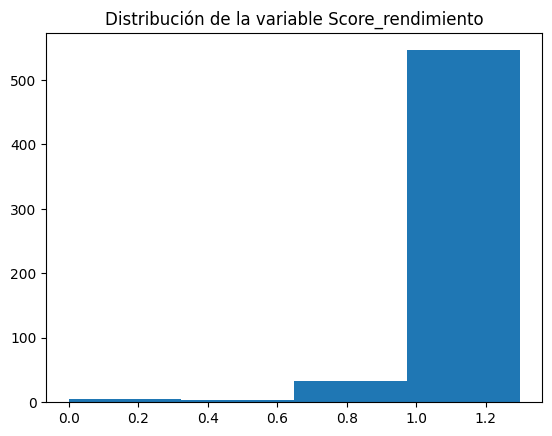

In [34]:
distr_hist(df_grouped_ID_month,'Score_rendimiento',4)

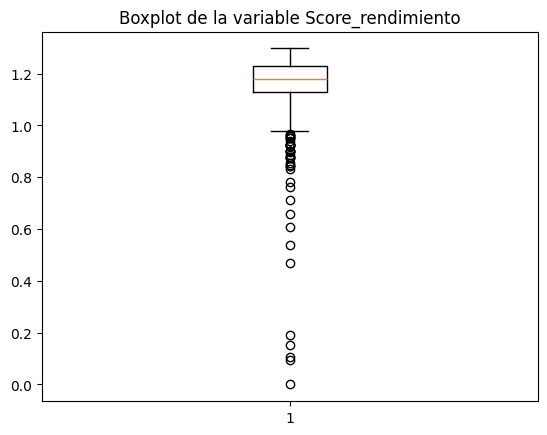

In [35]:
distr_boxplot(df_grouped_ID_month,'Score_rendimiento')

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
Los valores **outliers son menores a 0.74** (hay 41 registros), el mínimo es 0.

In [36]:
outliers_grouped_all = outliers_column(df_grouped_ID_month,'Score_rendimiento')
outliers_grouped_all.sort_values(
    by='Score_rendimiento',
    ascending=False
)

,ID,Month_absence,Month_absence_name,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours,Capacity,Disciplinary_component,HitNorm,Score_rendimiento,Score_rendimiento_norm
78,13,3.0,Marzo,17,12,251.616,87,1,8,0.9800,0.9,0.315789,0.965558,0.744598
388,188,12.0,Diciembre,13,18,377.550,94,0,80,0.8000,1.0,0.684211,0.964211,0.743559
498,298,3.0,Marzo,25,16,294.217,81,0,16,0.9600,1.0,0.000000,0.960000,0.740312
25,3,12.0,Diciembre,51,18,253.957,95,1,51,0.8725,0.9,0.736842,0.958832,0.739411
133,20,9.0,Septiembre,50,11,343.253,95,0,88,0.7800,1.0,0.736842,0.952421,0.734468
439,239,1.0,Enero,17,12,264.604,93,0,80,0.8000,1.0,0.631579,0.951579,0.733818
410,210,9.0,Septiembre,36,13,222.196,99,0,104,0.7400,1.0,0.947368,0.950316,0.732844
243,43,3.0,Marzo,36,13,294.217,81,0,24,0.9400,1.0,0.000000,0.940000,0.724889
92,14,11.0,Noviembre,12,14,237.656,99,0,111,0.7225,1.0,0.947368,0.927842,0.715513
415,215,9.0,Septiembre,14,16,222.196,99,0,112,0.7200,1.0,0.947368,0.924632,0.713038


**Subset rendimiento (anterior) agrupado ID**

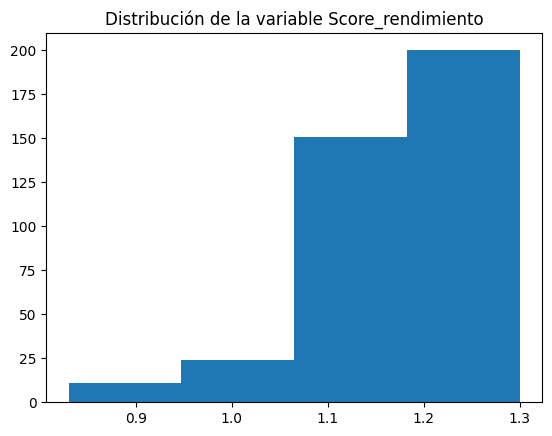

In [37]:
distr_hist(df_rendimiento_grouped_ID,'Score_rendimiento',4)

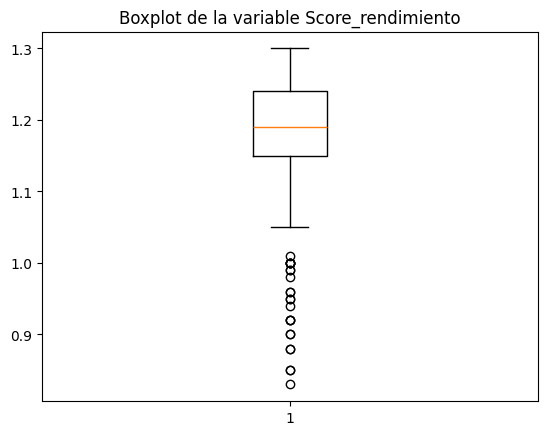

In [38]:
distr_boxplot(df_rendimiento_grouped_ID,'Score_rendimiento')

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
Los valores **outliers son menores a 1.01** (hay 25 registros), el mínimo es 0,83.

In [39]:
outliers_grouped_ID = outliers_column(df_rendimiento_grouped_ID,'Score_rendimiento')
outliers_grouped_ID.sort_values(
    by='Score_rendimiento',
    ascending=False
)

,ID,Distance_Residence_Work,Service_time,Work_load_Average_day,Hit_target,Disciplinary_failure,Absenteeism_hours,Score_rendimiento
185,186,12,14,280.549,98,0,80,1.01
71,72,13,18,294.217,81,0,1,1.00
92,93,50,11,265.017,88,1,0,1.00
336,337,27,6,265.017,88,1,0,1.00
324,325,50,11,265.017,88,1,0,1.00
194,195,20,13,265.017,88,1,0,1.00
177,178,31,12,294.217,81,0,4,0.99
188,189,31,12,294.217,81,0,3,0.99
370,371,20,13,294.217,81,0,8,0.98
297,298,25,16,294.217,81,0,16,0.96


### Definir categorías score

Sobre los cuartiles? Además lo que queremos como objetivo es que la capacidad sea 1 como base, entonces los menores de uno (que además son los outliers) podrían ser los de bajo rendimiento.  
Tres grupos: bajo/medio/alto (cómo definir medio/alto). Alto mayor 0,75?

Terciles

In [ ]:
df_rendimiento_grouped_ID['Score_clase'] = pd.qcut(
    df_rendimiento_grouped_ID['Score_rendimiento'],
    q=3,
    labels=['Q1 bajo', 'Q2 medio', 'Q3 alto']
)

In [41]:
df_rendimiento_grouped_ID['Score_clase'].value_counts()

Score_clase
Q1 bajo     157
Q2 medio    127
Q3 alto     102
Name: count, dtype: int64

In [43]:
df_rendimiento_grouped_ID.groupby('Score_clase')['Score_rendimiento'].describe().T

Score_clase,Q1 bajo,Q2 medio,Q3 alto
count,157.000000,127.000000,102.000000
mean,1.101656,1.204646,1.260392
std,0.079895,0.018636,0.014066
min,0.830000,1.180000,1.240000
25%,1.070000,1.190000,1.250000
50%,1.130000,1.210000,1.260000
75%,1.160000,1.220000,1.270000
max,1.170000,1.230000,1.300000


Cuartiles

In [44]:
df_rendimiento_grouped_ID['Score_clase_4'] = pd.qcut(
    df_rendimiento_grouped_ID['Score_rendimiento'],
    q=4,
    labels=['Q1 bajo', 'Q2 medio-bajo', 'Q3 medio-alto','Q4 alto']
)

In [45]:
df_rendimiento_grouped_ID['Score_clase_4'].value_counts()

Score_clase_4
Q1 bajo          112
Q3 medio-alto    100
Q2 medio-bajo     90
Q4 alto           84
Name: count, dtype: int64

In [46]:
df_rendimiento_grouped_ID.groupby('Score_clase_4')['Score_rendimiento'].describe().T

Score_clase_4,Q1 bajo,Q2 medio-bajo,Q3 medio-alto,Q4 alto
count,112.000000,90.000000,100.00000,84.000000
mean,1.075536,1.175111,1.22050,1.264762
std,0.080994,0.009743,0.01424,0.011457
min,0.830000,1.160000,1.20000,1.250000
25%,1.060000,1.170000,1.21000,1.260000
50%,1.090000,1.175000,1.22000,1.260000
75%,1.140000,1.180000,1.23000,1.270000
max,1.150000,1.190000,1.24000,1.300000


## Análisis descriptivo grupos

distribución, frecuencias, medias por grupo.  
El bajo rendimiento seguro y el alto puede.

## Influencia

RLM / Spearman / MWU, KW

## Perfiles

### Regresión logística multinomial  
Qué variables (antigüedad, carga, distancia) aumentan/reducen la probabilidad de estar en bajo/medio/alto rendimiento.

### Regresión lineal mixta?
*Yo sí que la haría, mirar respuesta chatGPT*
- Variable respuesta: Rendimiento (numérica, el score continuo).
- Objetivo: entender cómo las variables predictoras (antigüedad, carga, distancia) se asocian con el rendimiento numérico.

RLM es adecuado: rendimiento continuo, coeficientes interpretables.  
Pero no da perfiles clasificados, solo asociaciones numéricas.

**Perplexity**  
En tu caso:
Dado que el mentor dice que la pregunta es "sencilla" y quieres identificar perfiles con menor rendimiento:  
**Mejor opción**: descriptivo + regresión logística multinomial.
- Paso 1: cuartiles para categorizar bajo/medio/alto.
- Paso 2: logística para identificar qué factores aumentan el riesgo de bajo rendimiento.

El RLM sería más complejo y no te da perfiles clasificados, solo asociaciones con el score continuo.

Ahora mismo tenemos las dos técnicas, el RLM y la regresión logística multinomial.

Dado que pide si tiene influencia y que creemos perfiles, sería mejor hacer las dos técnicas (RLM para influencia y multinomial para perfil)?  
No necesitas hacer ambas técnicas para una pregunta que es esencialmente sencilla. Con la regresión logística multinomial puedes responder tanto a la influencia como a los perfiles:
1. ¿Tiene influencia?
La regresión logística multinomial ya te da la influencia:
- Variable respuesta: Rendimiento_cat (bajo/medio/alto).
- Predictores: antigüedad, carga laboral, distancia, disciplinary.
- Resultado: odds ratios que indican:

“Por cada año más de antigüedad, la probabilidad de estar en bajo rendimiento (vs alto) disminuye X%”.

“Los empleados con disciplinary=1 tienen Y veces más probabilidad de estar en bajo rendimiento”.

Esto ya responde a “¿qué variables tienen influencia en el rendimiento?”.

2. ¿Puedes identificar perfiles?  
Sí, la logística multinomial ya identifica perfiles:
- Los odds ratios te dicen qué combinaciones de características te llevan a bajo/medio/alto.

Puedes interpretar:

- Perfil de bajo rendimiento: empleados con X características (ej.: alta distancia + disciplinary=1 + baja antigüedad).
- Perfil de alto rendimiento: empleados con Y características.
- Si quieres reglas explícitas, puedes añadir un árbol de decisión complementario, pero no necesitas RLM.

**¿Por qué no RLM?**
RLM con rendimiento continuo te da coeficientes numéricos, pero:
- No categoriza empleados.
- No da perfiles claros de “bajo/medio/alto”.
- Es más difícil traducir a perfiles operativos para HR.
- Ya elegiste categorizar rendimiento con cuartiles, así que la lógica natural es logística multinomial, no RLM.

**Recomendación final**
Para una pregunta sencilla (“¿tiene influencia? ¿puedes identificar perfiles?”):

- Descriptivo: distribución, frecuencias, gráficos.
- Regresión logística multinomial:
    -Responde a “influencia” (odds ratios).
    - Responde a “perfiles” (qué características te llevan a bajo/medio/alto).

No necesitas RLM a menos que quieras:

- Mostrar que también probaste con rendimiento continuo.
- Comparar RLM vs. logística.
Pero eso añade complejidad sin necesidad.

**ChatGPT**
- Spearman → sí, como exploratorio
- *Mann-Whitney / Kruskal-Wallis → opcional, solo si comparáis grupos claramente definidos*
- RLM → sí, técnica principal para influencia
- Multinomial → sí, técnica principal para perfiles